# 1
- pure comp: molecular
- kij: molecular
- melting: molecular

In [1]:
using Pkg, Revise
using Clapeyron, PyCall
import PyPlot; const plt = PyPlot
import DataFrames

In [11]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter1 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_held,75.07,4.8495,2.3270,216.9600,2,2
propanol,60.10,2.9997,3.2522,233.4,1,1
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter1 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
propanol,glycine_held,0.053
water,glycine_held,-0.0612
water,propanol,-0.017
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter1 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
propanol,H,propanol,e,2276.8,0.015268
water,H,water,e,2425.67,0.045
glycine_held,H,glycine_held,e,2598.06,0.0393 
propanol,H,glycine_held,e,2437.43,0.023492
propanol,e,glycine_held,H,2437.43,0.023492
water,H,glycine_held,e,2511.865,0.041515
water,e,glycine_held,H,2511.865,0.041515
water,e,propanol,H,2351.235,0.025994
water,H,propanol,e,2351.235,0.025994
"""
components = ["water", "propanol", "glycine_held"]
model1 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter1, unlike_parameter1, assoc_parameter1])

println(model1.fluid.params.epsilon.values)
println(model1.fluid.params.sigma.values)
println("======================")
println(model1.fluid.params.epsilon_assoc.values)
println(model1.fluid.params.bondvol.values)
println("kij = ", (1  - ((model1.fluid.params.epsilon.values[2])/(sqrt(model1.fluid.params.epsilon.values[1] * model1.fluid.params.epsilon.values[4])))))
println("Hfus = ", model1.solid.params.Hfus[3])
println("Tm = ", model1.solid.params.Tm[3])

[353.94 292.3049716259441 294.07079841359604; 292.3049716259441 233.4 213.1033323563383; 294.07079841359604 213.1033323563383 216.96]
[2.8014570000000003e-10 3.0268285e-10 2.5642285e-10; 3.0268285e-10 3.2522000000000004e-10 2.7896000000000004e-10; 2.5642285e-10 2.7896000000000004e-10 2.327e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2425.67, 2351.235, 2351.235, 2511.865, 2511.865, 2276.8, 2437.43, 2437.43, 2598.06]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.045, 0.025994, 0.025994, 0.041515, 0.041515, 0.015268, 0.023492, 0.023492, 0.0393]
kij = 0.09123147328849934
Hfus = 17536.72
Tm = 714.3



=== HASIL PERHITUNGAN MODEL ===
100×2 DataFrame
 Row │ Fraksi_Propanol  Fraksi_Solute 
     │ Float64          Float64       
─────┼────────────────────────────────
   1 │       0.0         NaN
   2 │       0.010101      0.0812745
   3 │       0.020202      0.0777467
   4 │       0.030303      0.0741228
   5 │       0.040404      0.0704457
   6 │       0.0505051     0.066756
   7 │       0.0606061     0.0630918
   8 │       0.0707071     0.0594874
   9 │       0.0808081     0.055973
  10 │       0.0909091     0.0525735
  11 │       0.10101       0.0493091
  12 │       0.111111      0.0461943
  13 │       0.121212      0.043239
  14 │       0.131313      0.0404486
  15 │       0.141414      0.0378247
  16 │       0.151515      0.0353658
  17 │       0.161616      0.0330679
  18 │       0.171717      0.0309251
  19 │       0.181818      0.0289306
  20 │       0.191919      0.0270764
  21 │       0.20202       0.0253543
  22 │       0.212121      0.0237558
  23 │       0.222222      0.02

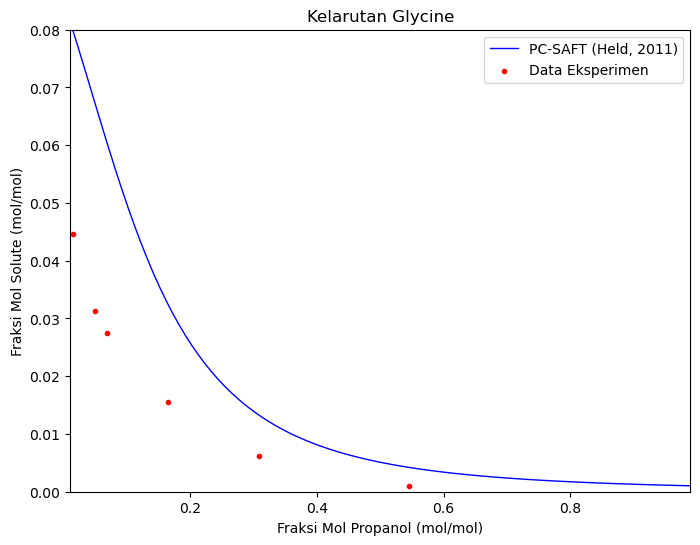

In [12]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_air_propanol.csv", DataFrame)

function plot_x(df)
    T = 298.15
    p = 101325
    x_propanol = LinRange(0.,1.,100)
    
    s = zeros(length(x_propanol))
    
    for i in 1:length(x_propanol)
        s[i] = sle_solubility(model1, p, T, [1-x_propanol[i],x_propanol[i],0.]; solute=["glycine_held"])[3]
    end

    df_hasil = DataFrame(
        Fraksi_Propanol = x_propanol,
        Fraksi_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(x_propanol, s, label="PC-SAFT (Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.x_propanol, df.out_s, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine")
    plt.xlabel("Fraksi Mol Propanol (mol/mol)")
    plt.ylabel("Fraksi Mol Solute (mol/mol)")
    
    plt.xlim(0.01, 0.99)
    plt.ylim(0., 0.08)
    
    plt.legend(loc="upper right")
    plt.savefig("1_plot_T_glycine_air_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_x(df_eksperimen)

In [9]:
using CSV, DataFrames, Printf

function solubility_gclow(model::EoSModel, x_propanol::Float64)
    T = 298.15
    p = 101325
    x2 = sle_solubility(model, p, T, [1-x_propanol,x_propanol,0.]; solute=["glycine_gclow"])[3]
    return x2
end

function solubility_gcmid(model::EoSModel, x_propanol::Float64)
    T = 298.15
    p = 101325
    x2 = sle_solubility(model, p, T, [1-x_propanol,x_propanol,0.]; solute=["glycine_gcmid"])[3]
    return x2
end

function solubility_gcup(model::EoSModel, x_propanol::Float64)
    T = 298.15
    p = 101325
    x2 = sle_solubility(model, p, T, [1-x_propanol,x_propanol,0.]; solute=["glycine_gcup"])[3]
    return x2
end

function solubility_held(model::EoSModel, x_propanol::Float64)
    T = 298.15
    p = 101325
    x2 = sle_solubility(model, p, T, [1-x_propanol,x_propanol,0.]; solute=["glycine_held"])[3]
    return x2
end

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [13]:
aard_p   = calculate_AAD(model1, "sol_glycine_air_propanol.csv", solubility_held)


=== AAD: sol_glycine_air_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0149      0.044705      0.079623      78.1081 
0.0487      0.031244      0.067421      115.7877
0.0678      0.027557      0.060499      119.5387
0.1646      0.015566      0.032414      108.2365
0.3083      0.006205      0.013260      113.6876
0.5448      0.000907      0.004222      365.6783
0.9999      0.000112      0.001004      795.6756
AARD = 242.3875%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


242.38749253058813

# 2
- pure comp: GC
- kij: GC
- melting: GC

In [14]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter2 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
propanol,60.10,2.9997,3.2522,233.4,1,1
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter2 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
propanol,glycine_gclow,0.055028
propanol,glycine_gcmid,0.055028
propanol,glycine_gcup,0.055028
water,glycine_gclow,0.0000296035176
water,glycine_gcmid,0.0000296035176
water,glycine_gcup,0.0000296035176
water,propanol,0.057428
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter2 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
propanol,H,propanol,e,2276.8,0.015268
water,H,water,e,2425.67,0.045
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
propanol,H,glycine_gclow,e,2644.459,0.060431
propanol,e,glycine_gclow,H,2644.459,0.060431
propanol,H,glycine_gcmid,e,2644.459,0.060431
propanol,e,glycine_gcmid,H,2644.459,0.060431
propanol,H,glycine_gcup,e,2644.459,0.060431
propanol,e,glycine_gcup,H,2644.459,0.060431
water,H,glycine_gclow,e,2718.894,0.107377
water,e,glycine_gclow,H,2718.894,0.107377
water,H,glycine_gcmid,e,2718.894,0.107377
water,e,glycine_gcmid,H,2718.894,0.107377
water,H,glycine_gcup,e,2718.894,0.107377
water,e,glycine_gcup,H,2718.894,0.107377
water,e,propanol,H,2351.235,0.025994
water,H,propanol,e,2351.235,0.025994
"""
components_low = ["water", "propanol", "glycine_gclow"]
components_mid = ["water", "propanol", "glycine_gcmid"]
components_up = ["water", "propanol", "glycine_gcup"]

model2_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])
model2_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter2, unlike_parameter2, assoc_parameter2])


println("low bound")
println("Hfus = ", model2_low.solid.params.Hfus[2])
println("Tm = ", model2_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model2_mid.solid.params.Hfus[2])
println("Tm = ", model2_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model2_up.solid.params.Hfus[2])
println("Tm = ", model2_up.solid.params.Tm[2])

low bound
Hfus = 5370.0
Tm = 147.0
mid bound
Hfus = 5370.0
Tm = 147.0
up bound
Hfus = 5370.0
Tm = 147.0



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Fraksi_Propanol  Fraksi_Solute_Low  Fraksi_Solute_Mid  Fraksi_Solute_Up 
     │ Float64          Float64            Float64            Float64          
─────┼─────────────────────────────────────────────────────────────────────────
   1 │       0.0             NaN               NaN               NaN
   2 │       0.0416667         0.0412821         0.00881596        0.0021974
   3 │       0.0833333         0.0382005         0.00895391        0.00227763
   4 │       0.125             0.0322804         0.00809431        0.0020961
   5 │       0.166667          0.0262022         0.0068909         0.00180861
   6 │       0.208333          0.0209231         0.00569201        0.00150854
   7 │       0.25              0.0166405         0.00463837        0.00123796
   8 │       0.291667          0.0132692         0.00376465        0.00100994
   9 │       0.333333          0.0106464         0.00306025        0.000824117
  10 │       0.375  

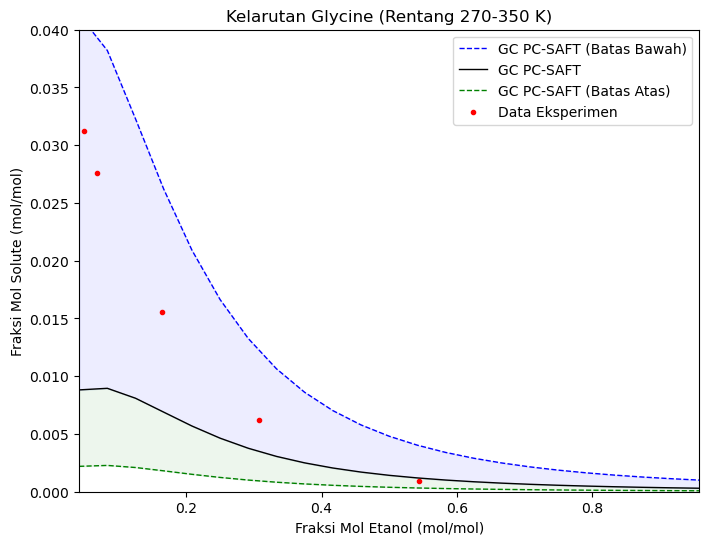

In [15]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_air_propanol.csv", DataFrame)

function plot_T(df)
    T = 298.15
    p = 101325
    x_propanol = LinRange(0.,1.,25)
    
    s_low = zeros(length(x_propanol))
    s_mid = zeros(length(x_propanol))
    s_up = zeros(length(x_propanol))

    
    for i in 1:length(x_propanol)
        s_low[i] = sle_solubility(model2_low, p, T, [1-x_propanol[i],x_propanol[i],0.]; solute=["glycine_gclow"])[3]
        s_mid[i] = sle_solubility(model2_mid, p, T, [1-x_propanol[i],x_propanol[i],0.]; solute=["glycine_gcmid"])[3]
        s_up[i]  = sle_solubility(model2_up, p, T, [1-x_propanol[i],x_propanol[i],0.]; solute=["glycine_gcup"])[3]
    end

    df_hasil = DataFrame(
        Fraksi_Propanol = x_propanol,
        Fraksi_Solute_Low = s_low,
        Fraksi_Solute_Mid = s_mid,
        Fraksi_Solute_Up = s_up,)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(x_propanol, s_low, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(x_propanol, s_mid, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(x_propanol, s_up, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_between(x_propanol, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_between(x_propanol, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.x_propanol, df.out_s, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Etanol (mol/mol)")
    plt.ylabel("Fraksi Mol Solute (mol/mol)")
    
    plt.xlim(0.0416667, 0.958333)
    plt.ylim(0.0, 0.04)
    
    plt.legend(loc="upper right")
    plt.savefig("2_plot_T_glycine_air_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)

In [19]:
aard_p   = calculate_AAD(model2_low, "sol_glycine_air_propanol.csv", solubility_gclow)


=== AAD: sol_glycine_air_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0149      0.044705      0.039179      12.3599 
0.0487      0.031244      0.041163      31.7483 
0.0678      0.027557      0.039906      44.8088 
0.1646      0.015566      0.026485      70.1493 
0.3083      0.006205      0.012142      95.6723 
0.5448      0.000907      0.003977      338.6707
0.9999      0.000112      0.000903      705.2593
AARD = 185.5241%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


185.52407242850194

In [20]:
aard_p   = calculate_AAD(model2_mid, "sol_glycine_air_propanol.csv", solubility_gcmid)


=== AAD: sol_glycine_air_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0149      0.044705      0.007821      82.5046 
0.0487      0.031244      0.008945      71.3701 
0.0678      0.027557      0.009063      67.1105 
0.1646      0.015566      0.006952      55.3408 
0.3083      0.006205      0.003464      44.1685 
0.5448      0.000907      0.001179      30.1003 
0.9999      0.000112      0.000271      142.1763
AARD = 70.3959%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


70.39588250057616

In [21]:
aard_p   = calculate_AAD(model2_up, "sol_glycine_air_propanol.csv", solubility_gcup)


=== AAD: sol_glycine_air_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0149      0.044705      0.001931      95.6816 
0.0487      0.031244      0.002237      92.8404 
0.0678      0.027557      0.002288      91.6969 
0.1646      0.015566      0.001824      88.2852 
0.3083      0.006205      0.000931      84.9972 
0.5448      0.000907      0.000321      64.6368 
0.9999      0.000112      0.000074      33.8905 
AARD = 78.8612%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


78.86123706245812

# 3
- pure comp: GC
- kij: GC
- melting: molecular

In [22]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter3 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_held,75.07,4.8492,2.2140,238.6085,2,2 
propanol,60.10,2.9997,3.2522,233.4,1,1
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter3 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
propanol,glycine_held,0.055028
water,glycine_held,0.0000296035176
water,propanol,0.057428
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter3 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
propanol,H,propanol,e,2276.8,0.015268
water,H,water,e,2425.67,0.045
glycine_held,H,glycine_held,e,3012.118,0.267058
propanol,H,glycine_held,e,2644.459,0.060431
propanol,e,glycine_held,H,2644.459,0.060431
water,H,glycine_held,e,2718.894,0.107377
water,e,glycine_held,H,2718.894,0.107377
water,e,propanol,H,2351.235,0.025994
water,H,propanol,e,2351.235,0.025994
"""
components = ["water", "propanol", "glycine_held"]
model3 = CompositeModel(components;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter3, unlike_parameter3, assoc_parameter3])

println(model3.fluid.params.epsilon.values)
println(model3.fluid.params.sigma.values)
println("======================")
println(model3.fluid.params.epsilon_assoc.values)
println(model3.fluid.params.bondvol.values)
println("kij = ", (1  - ((model3.fluid.params.epsilon.values[2])/(sqrt(model3.fluid.params.epsilon.values[1] * model3.fluid.params.epsilon.values[4])))))
println("Hfus = ", model3.solid.params.Hfus[2])
println("Tm = ", model3.solid.params.Tm[2])

[353.94 270.912961372084 290.59953948138354; 270.912961372084 233.4 223.00382975946988; 290.59953948138354 223.00382975946988 238.6085]
[2.8014570000000003e-10 3.0268285e-10 2.5077285000000003e-10; 3.0268285e-10 3.2522000000000004e-10 2.7331e-10; 2.5077285000000003e-10 2.7331e-10 2.214e-10]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[2425.67, 2351.235, 2351.235, 2718.894, 2718.894, 2276.8, 2644.459, 2644.459, 3012.118]
Clapeyron.Compressed4DMatrix{Float64, Vector{Float64}}[0.045, 0.025994, 0.025994, 0.107377, 0.107377, 0.015268, 0.060431, 0.060431, 0.267058]
kij = 0.12511681714877965
Hfus = 5370.0
Tm = 147.0



=== HASIL PERHITUNGAN MODEL ===
25×2 DataFrame
 Row │ Fraksi_Propanol  Fraksi_Solute 
     │ Float64          Float64       
─────┼────────────────────────────────
   1 │       0.0        NaN
   2 │       0.0416667    0.00832849
   3 │       0.0833333    0.00847156
   4 │       0.125        0.007668
   5 │       0.166667     0.0065341
   6 │       0.208333     0.00540091
   7 │       0.25         0.00440329
   8 │       0.291667     0.00357512
   9 │       0.333333     0.00290694
  10 │       0.375        0.00237473
  11 │       0.416667     0.00195253
  12 │       0.458333     0.00161725
  13 │       0.5          0.00134991
  14 │       0.541667     0.00113551
  15 │       0.583333     0.000962407
  16 │       0.625        0.000821635
  17 │       0.666667     0.000706311
  18 │       0.708333     0.000611142
  19 │       0.75         0.000532043
  20 │       0.791667     0.000465844
  21 │       0.833333     0.000410072
  22 │       0.875        0.000362786
  23 │       0.916667    

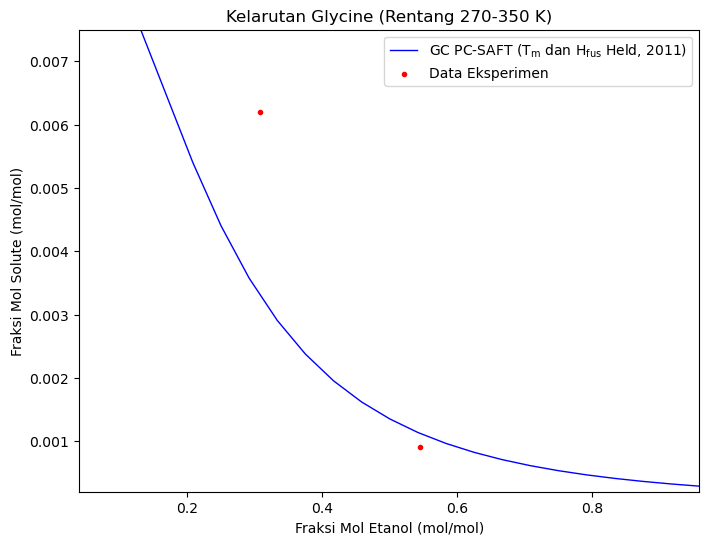

In [26]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_glycine_air_propanol.csv", DataFrame)

function plot_T(df)
    T = 298.15
    p = 101325
    x_propanol = LinRange(0.,1.,25)
    
    s = zeros(length(x_propanol))
    
    for i in 1:length(x_propanol)
        s[i] = sle_solubility(model3, p, T, [1-x_propanol[i],x_propanol[i],0.]; solute=["glycine_held"])[3]
    end

    df_hasil = DataFrame(
        Fraksi_Propanol = x_propanol,
        Fraksi_Solute = s)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(x_propanol, s, label=L"GC PC-SAFT ($\text{T}_{\text{m}}$ dan $\text{H}_{\text{fus}}$ Held, 2011)", color="blue", linewidth=1)

    plt.scatter(df.x_propanol, df.out_s, label = "Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Etanol (mol/mol)")
    plt.ylabel("Fraksi Mol Solute (mol/mol)")
    
    plt.xlim(0.04, 0.958)
    plt.ylim(0.0002, 0.0075)
    
    plt.legend(loc="upper right")
    plt.savefig("3_plot_T_glycine_air_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)

In [27]:
aard_p   = calculate_AAD(model3, "sol_glycine_air_propanol.csv", solubility_held)


=== AAD: sol_glycine_air_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0149      0.044705      0.007383      83.4848 
0.0487      0.031244      0.008453      72.9464 
0.0678      0.027557      0.008571      68.8994 
0.1646      0.015566      0.006591      57.6549 
0.3083      0.006205      0.003290      46.9734 
0.5448      0.000907      0.001121      23.6614 
0.9999      0.000112      0.000258      130.2575
AARD = 69.1254%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


69.12539284753973

# 4
- pure comp: GC
- kij: molecular
- melting: GC

In [28]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter4 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
propanol,60.10,2.9997,3.2522,233.4,1,1
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter4 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
propanol,glycine_gclow,0.053
propanol,glycine_gcmid,0.053
propanol,glycine_gcup,0.053
water,glycine_gclow,-0.0612
water,glycine_gcmid,-0.0612
water,glycine_gcup,-0.0612
water,propanol,0.058
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter4 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
propanol,H,propanol,e,2276.8,0.015268
water,H,water,e,2425.67,0.045
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
propanol,H,glycine_gclow,e,2644.459,0.060431
propanol,e,glycine_gclow,H,2644.459,0.060431
propanol,H,glycine_gcmid,e,2644.459,0.060431
propanol,e,glycine_gcmid,H,2644.459,0.060431
propanol,H,glycine_gcup,e,2644.459,0.060431
propanol,e,glycine_gcup,H,2644.459,0.060431
water,H,glycine_gclow,e,2718.894,0.107377
water,e,glycine_gclow,H,2718.894,0.107377
water,H,glycine_gcmid,e,2718.894,0.107377
water,e,glycine_gcmid,H,2718.894,0.107377
water,H,glycine_gcup,e,2718.894,0.107377
water,e,glycine_gcup,H,2718.894,0.107377
water,e,propanol,H,2351.235,0.025994
water,H,propanol,e,2351.235,0.025994
"""
components_low = ["water", "propanol", "glycine_gclow"]
components_mid = ["water", "propanol", "glycine_gcmid"]
components_up = ["water", "propanol", "glycine_gcup"]

model4_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])
model4_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter4, unlike_parameter4, assoc_parameter4])


println("low bound")
println("Hfus = ", model4_low.solid.params.Hfus[2])
println("Tm = ", model4_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model4_mid.solid.params.Hfus[2])
println("Tm = ", model4_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model4_up.solid.params.Hfus[2])
println("Tm = ", model4_up.solid.params.Tm[2])

low bound
Hfus = 5370.0
Tm = 147.0
mid bound
Hfus = 5370.0
Tm = 147.0
up bound
Hfus = 5370.0
Tm = 147.0



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Fraksi_Propanol  Fraksi_Solute_Low  Fraksi_Solute_Mid  Fraksi_Solute_Up 
     │ Float64          Float64            Float64            Float64          
─────┼─────────────────────────────────────────────────────────────────────────
   1 │       0.0             NaN               NaN               NaN
   2 │       0.0416667         0.199606          0.0819942         0.021448
   3 │       0.0833333         0.176399          0.0623717         0.0157845
   4 │       0.125             0.146271          0.0442591         0.011109
   5 │       0.166667          0.11229           0.0304122         0.00770925
   6 │       0.208333          0.0802067         0.020849          0.00536526
   7 │       0.25              0.0552277         0.0144801         0.00377821
   8 │       0.291667          0.0381039         0.010249          0.00270379
   9 │       0.333333          0.0268395         0.00740443        0.00196969
  10 │       0.375      

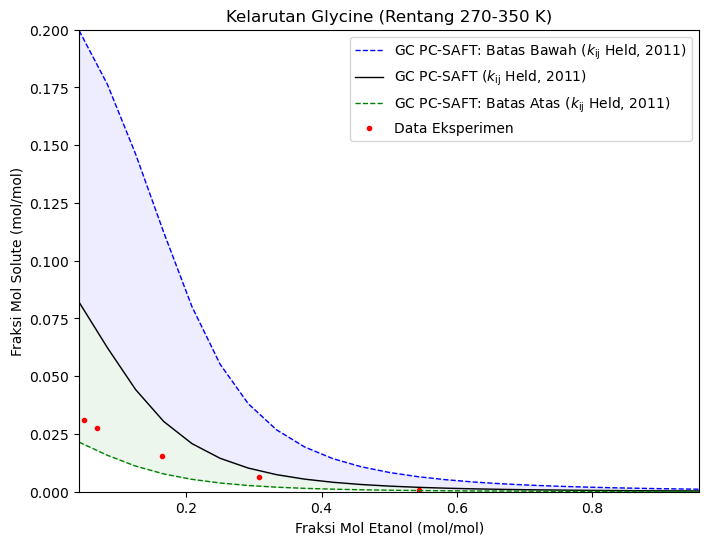

In [37]:
using Clapeyron
using CSV
using DataFrames
using LaTeXStrings

df_eksperimen = CSV.read("fig_glycine_air_propanol.csv", DataFrame)

function plot_T(df)
    T = 298.15
    p = 101325
    x_propanol = LinRange(0.,1.,25)
    
    s_low = zeros(length(x_propanol))
    s_mid = zeros(length(x_propanol))
    s_up = zeros(length(x_propanol))


    
    for i in 1:length(x_propanol)
        s_low[i] = sle_solubility(model4_low, p, T, [1-x_propanol[i],x_propanol[i],0.]; solute=["glycine_gclow"])[3]
        s_mid[i] = sle_solubility(model4_mid, p, T, [1-x_propanol[i],x_propanol[i],0.]; solute=["glycine_gcmid"])[3]
        s_up[i]  = sle_solubility(model4_up, p, T, [1-x_propanol[i],x_propanol[i],0.]; solute=["glycine_gcup"])[3]
    end

    df_hasil = DataFrame(
        Fraksi_Propanol = x_propanol,
        Fraksi_Solute_Low = s_low,
        Fraksi_Solute_Mid = s_mid,
        Fraksi_Solute_Up = s_up,)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(x_propanol, s_low, label=L"GC PC-SAFT: Batas Bawah ($k_{\text{ij}}$ Held, 2011)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(x_propanol, s_mid, label=L"GC PC-SAFT ($k_{\text{ij}}$ Held, 2011)", color="black", linestyle="-", linewidth=1.)
    plt.plot(x_propanol, s_up, label=L"GC PC-SAFT: Batas Atas ($k_{\text{ij}}$ Held, 2011)", color="green", linestyle="--", linewidth=1.)

    plt.fill_between(x_propanol, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_between(x_propanol, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.x_propanol, df.out_s, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Etanol (mol/mol)")
    plt.ylabel("Fraksi Mol Solute (mol/mol)")
    
    plt.xlim(0.0416667, 0.958333)
    plt.ylim(0.0, 0.2)
    
    plt.legend(loc="upper right")
    plt.savefig("4_plot_T_glycine_air_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)

In [30]:
aard_p   = calculate_AAD(model4_low, "sol_glycine_air_propanol.csv", solubility_gclow)


=== AAD: sol_glycine_air_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0149      0.044705      0.210219      370.2366
0.0487      0.031244      0.196249      528.1163
0.0678      0.027557      0.185922      574.6687
0.1646      0.015566      0.113966      632.1526
0.3083      0.006205      0.033032      432.3366
0.5448      0.000907      0.006437      610.0507
0.9999      0.000112      0.000951      748.2303
AARD = 556.5417%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


556.5416828189099

In [31]:
aard_p   = calculate_AAD(model4_mid, "sol_glycine_air_propanol.csv", solubility_gcmid)


=== AAD: sol_glycine_air_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0149      0.044705      0.093069      108.1842
0.0487      0.031244      0.078789      152.1726
0.0678      0.027557      0.069731      153.0389
0.1646      0.015566      0.030984      99.0510 
0.3083      0.006205      0.008979      44.7075 
0.5448      0.000907      0.001893      108.7962
0.9999      0.000112      0.000286      155.0485
AARD = 117.2856%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


117.2855596579305

In [32]:
aard_p   = calculate_AAD(model4_up, "sol_glycine_air_propanol.csv", solubility_gcup)


=== AAD: sol_glycine_air_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0149      0.044705      0.024903      44.2941 
0.0487      0.031244      0.020472      34.4768 
0.0678      0.027557      0.017822      35.3280 
0.1646      0.015566      0.007849      49.5768 
0.3083      0.006205      0.002377      61.6865 
0.5448      0.000907      0.000513      43.3918 
0.9999      0.000112      0.000078      30.3810 
AARD = 42.7335%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


42.733549385803634

# 5
- pure comp: GC
- kij: 0
- melting: GC

In [33]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter5 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
propanol,60.10,2.9997,3.2522,233.4,1,1
water,18.02,1.2047,2.801457,353.94,1,11
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter5 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
propanol,glycine_gclow,0
propanol,glycine_gcmid,0
propanol,glycine_gcup,0
water,glycine_gclow,0
water,glycine_gcmid,0
water,glycine_gcup,0
water,propanol,0
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter5 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
propanol,H,propanol,e,2276.8,0.015268
water,H,water,e,2425.67,0.045
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
propanol,H,glycine_gclow,e,2644.459,0.060431
propanol,e,glycine_gclow,H,2644.459,0.060431
propanol,H,glycine_gcmid,e,2644.459,0.060431
propanol,e,glycine_gcmid,H,2644.459,0.060431
propanol,H,glycine_gcup,e,2644.459,0.060431
propanol,e,glycine_gcup,H,2644.459,0.060431
water,H,glycine_gclow,e,2718.894,0.107377
water,e,glycine_gclow,H,2718.894,0.107377
water,H,glycine_gcmid,e,2718.894,0.107377
water,e,glycine_gcmid,H,2718.894,0.107377
water,H,glycine_gcup,e,2718.894,0.107377
water,e,glycine_gcup,H,2718.894,0.107377
water,e,propanol,H,2351.235,0.025994
water,H,propanol,e,2351.235,0.025994
"""
components_low = ["water", "propanol", "glycine_gclow"]
components_mid = ["water", "propanol", "glycine_gcmid"]
components_up = ["water", "propanol", "glycine_gcup"]

model5_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])
model5_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter5, unlike_parameter5, assoc_parameter5])


println("low bound")
println("Hfus = ", model5_low.solid.params.Hfus[2])
println("Tm = ", model5_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model5_mid.solid.params.Hfus[2])
println("Tm = ", model5_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model5_up.solid.params.Hfus[2])
println("Tm = ", model5_up.solid.params.Tm[2])

low bound
Hfus = 5370.0
Tm = 147.0
mid bound
Hfus = 5370.0
Tm = 147.0
up bound
Hfus = 5370.0
Tm = 147.0



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Fraksi_Propanol  Fraksi_Solute_Low  Fraksi_Solute_Mid  Fraksi_Solute_Up 
     │ Float64          Float64            Float64            Float64          
─────┼─────────────────────────────────────────────────────────────────────────
   1 │       0.0             NaN                NaN              NaN
   2 │       0.0416667         0.358027           0.158479         0.0322125
   3 │       0.0833333         0.344023           0.144056         0.0315831
   4 │       0.125             0.326299           0.126596         0.0286702
   5 │       0.166667          0.304874           0.108011         0.0249555
   6 │       0.208333          0.279763           0.0899969        0.0211859
   7 │       0.25              0.251151           0.0737663        0.017708
   8 │       0.291667          0.219659           0.0598825        0.0146554
   9 │       0.333333          0.186625           0.0483837        0.0120526
  10 │       0.375          

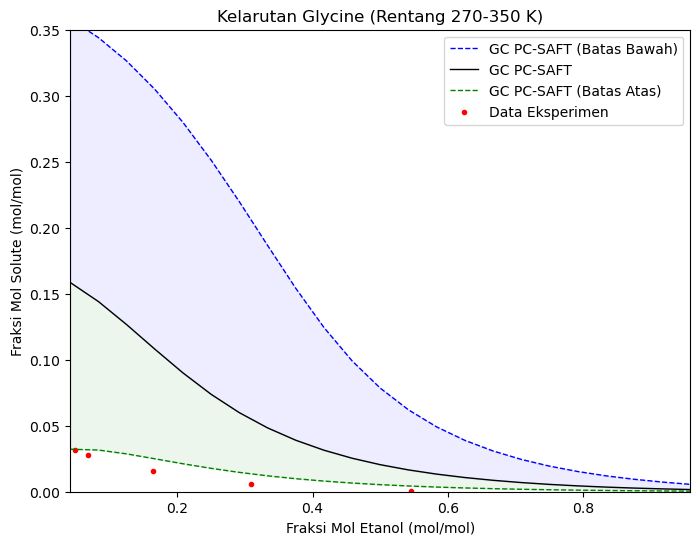

In [38]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_air_propanol.csv", DataFrame)

function plot_T(df)
    T = 298.15
    p = 101325
    x_propanol = LinRange(0.,1.,25)
    
    s_low = zeros(length(x_propanol))
    s_mid = zeros(length(x_propanol))
    s_up = zeros(length(x_propanol))

    
    for i in 1:length(x_propanol)
        s_low[i] = sle_solubility(model5_low, p, T, [1-x_propanol[i],x_propanol[i],0.]; solute=["glycine_gclow"])[3]
        s_mid[i] = sle_solubility(model5_mid, p, T, [1-x_propanol[i],x_propanol[i],0.]; solute=["glycine_gcmid"])[3]
        s_up[i]  = sle_solubility(model5_up, p, T, [1-x_propanol[i],x_propanol[i],0.]; solute=["glycine_gcup"])[3]
    end

    df_hasil = DataFrame(
        Fraksi_Propanol = x_propanol,
        Fraksi_Solute_Low = s_low,
        Fraksi_Solute_Mid = s_mid,
        Fraksi_Solute_Up = s_up,)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(x_propanol, s_low, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(x_propanol, s_mid, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(x_propanol, s_up, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_between(x_propanol, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_between(x_propanol, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.x_propanol, df.out_s, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Etanol (mol/mol)")
    plt.ylabel("Fraksi Mol Solute (mol/mol)")
    
    plt.xlim(0.0416667, 0.958333)
    plt.ylim(0.0, 0.35)
    
    plt.legend(loc="upper right")
    plt.savefig("5_plot_T_glycine_air_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)

In [39]:
aard_p   = calculate_AAD(model5_low, "sol_glycine_air_propanol.csv", solubility_gclow)


=== AAD: sol_glycine_air_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0149      0.044705      0.365004      716.4747
0.0487      0.031244      0.355934      1039.2042
0.0678      0.027557      0.349665      1168.8596
0.1646      0.015566      0.306011      1865.9001
0.3083      0.006205      0.206553      3228.7312
0.5448      0.000907      0.060958      6624.0114


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


0.9999      0.000112      0.003735      3232.5934
AARD = 2553.6821%


2553.6821002079714

In [40]:
aard_p   = calculate_AAD(model5_mid, "sol_glycine_air_propanol.csv", solubility_gcmid)


=== AAD: sol_glycine_air_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


0.0149      0.044705      0.165165      269.4563
0.0487      0.031244      0.156349      400.4125
0.0678      0.027557      0.149877      443.8691
0.1646      0.015566      0.108921      599.7389
0.3083      0.006205      0.055016      786.6130
0.5448      0.000907      0.016274      1695.0929
0.9999      0.000112      0.001111      891.6252
AARD = 726.6868%


726.6868380288598

In [41]:
aard_p   = calculate_AAD(model5_up, "sol_glycine_air_propanol.csv", solubility_gcup)


=== AAD: sol_glycine_air_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0149      0.044705      0.030222      32.3967 
0.0487      0.031244      0.032363      3.5822  
0.0678      0.027557      0.032196      16.8328 
0.1646      0.015566      0.025143      61.5257 
0.3083      0.006205      0.013563      118.5787
0.5448      0.000907      0.004287      372.9073
0.9999      0.000112      0.000302      169.8072
AARD = 110.8044%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


110.80438562606085

# 6
- pure comp: GC
- kij: molecular (VLE GC)
- melting: GC

In [42]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter6 = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
glycine_gclow,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcmid,75.07,4.8492,2.2140,238.6085,2,2
glycine_gcup,75.07,4.8492,2.2140,238.6085,2,2 
propanol,60.10,2.9997,3.2522,233.4,1,1
water,18.02,1.2047,2.801457,353.94,1,1
"""
# GC glycine1,75.07,4.8492,2.2140,238.6085,2,2 
# Held glycine1,75.07,4.8495,2.3270,216.9600,2,2 

unlike_parameter6 = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
propanol,glycine_gclow,0.055800569
propanol,glycine_gcmid,0.055800569
propanol,glycine_gcup,0.055800569
water,glycine_gclow,0.000013527940174729
water,glycine_gcmid,0.000013527940174729
water,glycine_gcup,0.000013527940174729
water,propanol,0.024378004
"""

# GC kij = 0.0000296035176
# Held kij = -0.0612

#jgn lupa combing rules yh
assoc_parameter6 = """Clapeyron Database File
PCSAFT Assoc Parameters [csvtype = assoc,grouptype = PCSAFT]
species1,site1,species2,site2,epsilon_assoc,bondvol
propanol,H,propanol,e,2276.8,0.015268
water,H,water,e,2425.67,0.045
glycine_gclow,H,glycine_gclow,e,3012.118,0.267058
glycine_gcmid,H,glycine_gcmid,e,3012.118,0.267058 
glycine_gcup,H,glycine_gcup,e,3012.118,0.267058 
propanol,H,glycine_gclow,e,2644.459,0.060431
propanol,e,glycine_gclow,H,2644.459,0.060431
propanol,H,glycine_gcmid,e,2644.459,0.060431
propanol,e,glycine_gcmid,H,2644.459,0.060431
propanol,H,glycine_gcup,e,2644.459,0.060431
propanol,e,glycine_gcup,H,2644.459,0.060431
water,H,glycine_gclow,e,2718.894,0.107377
water,e,glycine_gclow,H,2718.894,0.107377
water,H,glycine_gcmid,e,2718.894,0.107377
water,e,glycine_gcmid,H,2718.894,0.107377
water,H,glycine_gcup,e,2718.894,0.107377
water,e,glycine_gcup,H,2718.894,0.107377
water,e,propanol,H,2351.235,0.025994
water,H,propanol,e,2351.235,0.025994
"""
components_low = ["water", "propanol", "glycine_gclow"]
components_mid = ["water", "propanol", "glycine_gcmid"]
components_up = ["water", "propanol", "glycine_gcup"]

model6_low = CompositeModel(components_low;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_mid = CompositeModel(components_mid;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])
model6_up = CompositeModel(components_up;
                       fluid = PCSAFT,
                       solid = SolidHfus,
                       fluid_userlocations = [like_parameter6, unlike_parameter6, assoc_parameter6])


println("low bound")
println("Hfus = ", model6_low.solid.params.Hfus[2])
println("Tm = ", model6_low.solid.params.Tm[2])

println("mid bound")
println("Hfus = ", model6_mid.solid.params.Hfus[2])
println("Tm = ", model6_mid.solid.params.Tm[2])

println("up bound")
println("Hfus = ", model6_up.solid.params.Hfus[2])
println("Tm = ", model6_up.solid.params.Tm[2])

low bound
Hfus = 5370.0
Tm = 147.0
mid bound
Hfus = 5370.0
Tm = 147.0
up bound
Hfus = 5370.0
Tm = 147.0



=== HASIL PERHITUNGAN MODEL ===
25×4 DataFrame
 Row │ Fraksi_Propanol  Fraksi_Solute_Low  Fraksi_Solute_Mid  Fraksi_Solute_Up 
     │ Float64          Float64            Float64            Float64          
─────┼─────────────────────────────────────────────────────────────────────────
   1 │       0.0             NaN               NaN               NaN
   2 │       0.0416667         0.035903          0.00781388        0.00196002
   3 │       0.0833333         0.0314026         0.00750124        0.00192083
   4 │       0.125             0.0259928         0.00662775        0.00172578
   5 │       0.166667          0.0210456         0.00561303        0.0014796
   6 │       0.208333          0.0169233         0.00465648        0.00123826
   7 │       0.25              0.0136186         0.00383035        0.001025
   8 │       0.291667          0.0110116         0.00314623        0.00084578
   9 │       0.333333          0.00896506        0.00259115        0.000698912
  10 │       0.375   

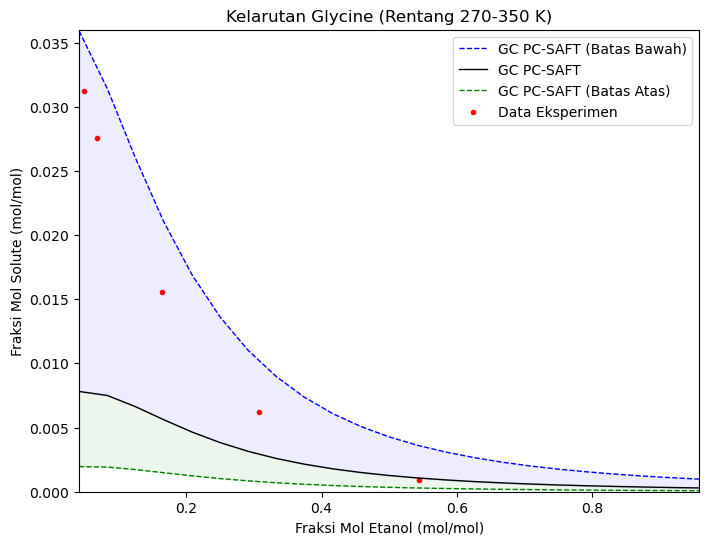

In [44]:
using Clapeyron
using CSV
using DataFrames

df_eksperimen = CSV.read("fig_glycine_air_propanol.csv", DataFrame)

function plot_T(df)
    T = 298.15
    p = 101325
    x_propanol = LinRange(0.,1.,25)
    
    s_low = zeros(length(x_propanol))
    s_mid = zeros(length(x_propanol))
    s_up = zeros(length(x_propanol))

    
    for i in 1:length(x_propanol)
        s_low[i] = sle_solubility(model6_low, p, T, [1-x_propanol[i],x_propanol[i],0.]; solute=["glycine_gclow"])[3]
        s_mid[i] = sle_solubility(model6_mid, p, T, [1-x_propanol[i],x_propanol[i],0.]; solute=["glycine_gcmid"])[3]
        s_up[i]  = sle_solubility(model6_up, p, T, [1-x_propanol[i],x_propanol[i],0.]; solute=["glycine_gcup"])[3]
    end

    df_hasil = DataFrame(
        Fraksi_Propanol = x_propanol,
        Fraksi_Solute_Low = s_low,
        Fraksi_Solute_Mid = s_mid,
        Fraksi_Solute_Up = s_up,)
    # Tampilkan di output terminal
    println("\n=== HASIL PERHITUNGAN MODEL ===")
    show(df_hasil, allrows=true)
    println("\n")

    plt.figure(figsize=(8, 6))
    
    plt.plot(x_propanol, s_low, label="GC PC-SAFT (Batas Bawah)", color="blue", linestyle="--", linewidth=1.)
    plt.plot(x_propanol, s_mid, label="GC PC-SAFT", color="black", linestyle="-", linewidth=1.)
    plt.plot(x_propanol, s_up, label="GC PC-SAFT (Batas Atas)", color="green", linestyle="--", linewidth=1.)

    plt.fill_between(x_propanol, s_mid, s_up, color="green", alpha=0.07)
    plt.fill_between(x_propanol, s_low, s_mid, color="blue", alpha=0.07)

    plt.scatter(df.x_propanol, df.out_s, label="Data Eksperimen", color="red", marker=".", zorder=1)
    
    plt.title("Kelarutan Glycine (Rentang 270-350 K)")
    plt.xlabel("Fraksi Mol Etanol (mol/mol)")
    plt.ylabel("Fraksi Mol Solute (mol/mol)")
    
    plt.xlim(0.0416667, 0.958333)
    plt.ylim(0.0, 0.036)
    
    plt.legend(loc="upper right")
    plt.savefig("6_plot_T_glycine_air_propanol.png", dpi=450, bbox_inches="tight") #GANTI NAMANYA DULU
end

plot_T(df_eksperimen)

In [45]:
aard_p   = calculate_AAD(model6_low, "sol_glycine_air_propanol.csv", solubility_gclow)


=== AAD: sol_glycine_air_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0149      0.044705      0.036708      17.8871 
0.0487      0.031244      0.035326      13.0660 
0.0678      0.027557      0.033311      20.8774 
0.1646      0.015566      0.021270      36.6432 
0.3083      0.006205      0.010135      63.3266 
0.5448      0.000907      0.003580      294.9027
0.9999      0.000112      0.000885      689.4815
AARD = 162.3121%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


162.3120884098033

In [46]:
aard_p   = calculate_AAD(model6_mid, "sol_glycine_air_propanol.csv", solubility_gcmid)


=== AAD: sol_glycine_air_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0149      0.044705      0.007418      83.4074 
0.0487      0.031244      0.007827      74.9499 
0.0678      0.027557      0.007714      72.0077 
0.1646      0.015566      0.005662      63.6231 
0.3083      0.006205      0.002910      53.0996 
0.5448      0.000907      0.001063      17.2998 
0.9999      0.000112      0.000266      137.4487
AARD = 71.6909%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


71.69089444060941

In [47]:
aard_p   = calculate_AAD(model6_up, "sol_glycine_air_propanol.csv", solubility_gcup)


=== AAD: sol_glycine_air_propanol.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.0149      0.044705      0.001837      95.8906 
0.0487      0.031244      0.001970      93.6938 
0.0678      0.027557      0.001961      92.8846 
0.1646      0.015566      0.001492      90.4159 
0.3083      0.006205      0.000783      87.3736 
0.5448      0.000907      0.000289      68.1013 
0.9999      0.000112      0.000073      35.1796 
AARD = 80.5056%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


80.50564957795281